In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# This file says which audio clips are real and which are fake
protocol_path = r"C:\deepfake-project\data\asvspoof\ASVspoof2019_LA_cm_protocols\ASVspoof2019.LA.cm.train.trn.txt"

# Column names taken from the ASVspoof readme
df = pd.read_csv(protocol_path, sep=" ", header=None, 
                 names=["speaker", "file_id", "env", "attack", "label"])

print(df.head(10))
print(f"\nTotal files: {len(df)}")
print(f"Bonafide (real): {(df['label'] == 'bonafide').sum()}")
print(f"Spoof (fake):    {(df['label'] == 'spoof').sum()}")

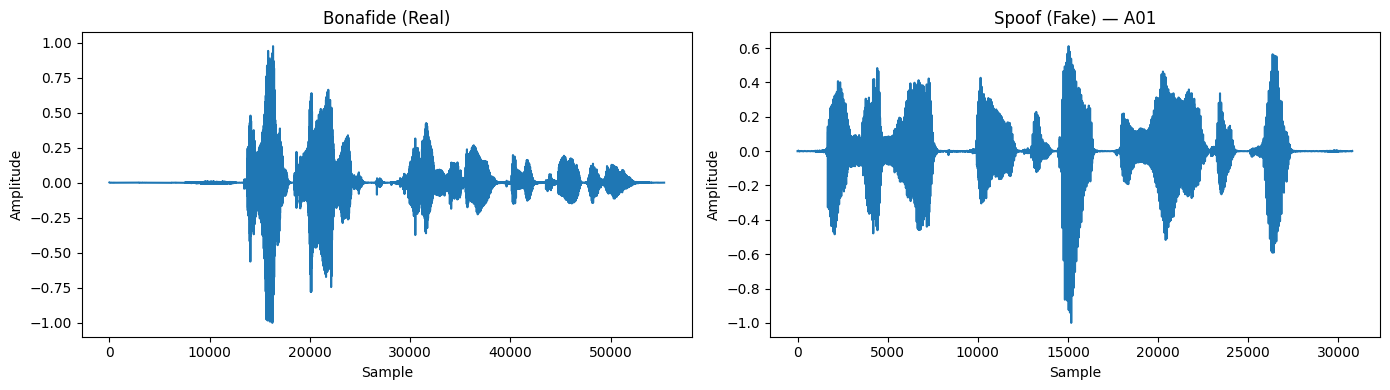

Real audio — duration: 3.46s, samples: 55329
Fake audio — duration: 1.92s, samples: 30769


In [3]:
import os

# Load one bonafide file
real_file = r"C:\deepfake-project\data\asvspoof\ASVspoof2019_LA_train\flac\LA_T_1138215.flac"
real_audio, sr = librosa.load(real_file, sr=16000)

# Get the first spoof file from the dataframe
spoof_row = df[df['label'] == 'spoof'].iloc[0]
spoof_file = rf"C:\deepfake-project\data\asvspoof\ASVspoof2019_LA_train\flac\{spoof_row['file_id']}.flac"
spoof_audio, sr = librosa.load(spoof_file, sr=16000)

# Plot both waveforms side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(real_audio)
axes[0].set_title("Bonafide (Real)")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")

axes[1].plot(spoof_audio)
axes[1].set_title(f"Spoof (Fake) — {spoof_row['attack']}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

print(f"Real audio — duration: {len(real_audio)/sr:.2f}s, samples: {len(real_audio)}")
print(f"Fake audio — duration: {len(spoof_audio)/sr:.2f}s, samples: {len(spoof_audio)}")

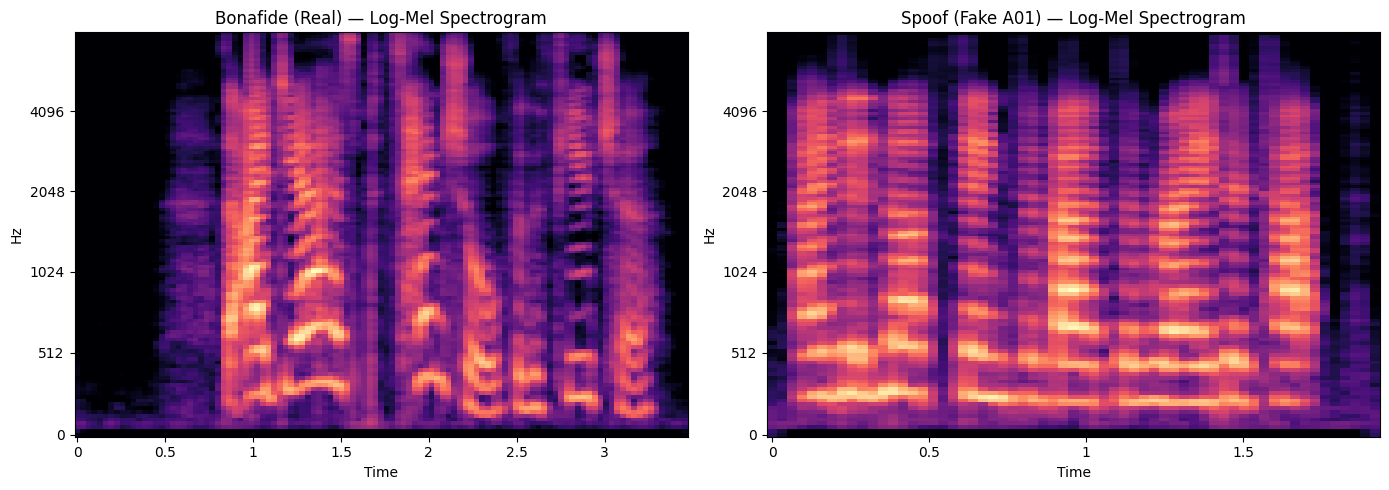

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real audio spectrogram
mel_real = librosa.feature.melspectrogram(y=real_audio, sr=sr, n_mels=128)
mel_real_db = librosa.power_to_db(mel_real, ref=np.max)
librosa.display.specshow(mel_real_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[0])
axes[0].set_title('Bonafide (Real) — Log-Mel Spectrogram')

# Fake audio spectrogram
mel_fake = librosa.feature.melspectrogram(y=spoof_audio, sr=sr, n_mels=128)
mel_fake_db = librosa.power_to_db(mel_fake, ref=np.max)
librosa.display.specshow(mel_fake_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Spoof (Fake A01) — Log-Mel Spectrogram')

plt.tight_layout()
plt.show()

In [5]:
# Read the validated Common Voice clips list
cv_path = r"C:\deepfake-project\data\commonvoice\cv-corpus-24.0-2025-12-05\en\validated.tsv"
cv_df = pd.read_csv(cv_path, sep="\t")

print(cv_df.columns.tolist())
print(f"Total validated clips: {len(cv_df)}")
cv_df.head(3)

C:\Users\tkell\AppData\Local\Temp\ipykernel_16388\2753114171.py:3: DtypeWarning: Columns (0: sentence_domain) have mixed types. Specify dtype option on import or set low_memory=False.
  cv_df = pd.read_csv(cv_path, sep="\t")


['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']
Total validated clips: 1869341


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,00095e762ba9e83fbffc38d3617aaeaa9bfd94d9f586c5...,common_voice_en_18127094.mp3,3343e59984bbb29777f68734d81dc9a9855b8c40d8b4ac...,"Yes, this is the right place.",NaN,2,0,NaN,NaN,NaN,NaN,en,NaN
1,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,common_voice_en_27710027.mp3,b2cf0b3308b6e00b46f3e48fe59682452ae737a596aa29...,"Joe Keaton disapproved of films, and Buster al...",NaN,3,1,NaN,NaN,NaN,NaN,en,NaN
2,0013037a1d45cc33460806cc3f8ecee9d536c45639ba4c...,common_voice_en_699711.mp3,de9d68400821d73ee6868687d0562c60282ee9446d1191...,She'll be all right.,NaN,2,1,NaN,NaN,NaN,NaN,en,NaN


In [6]:
# Take a random sample of 2000 clips
cv_sample = cv_df.sample(n=2000, random_state=42).reset_index(drop=True)

# Check what the full file path looks like
clips_folder = r"C:\deepfake-project\data\commonvoice\cv-corpus-24.0-2025-12-05\en\clips"
sample_path = os.path.join(clips_folder, cv_sample['path'][0])

print(f"Sample file path: {sample_path}")
print(f"File exists: {os.path.exists(sample_path)}")
print(f"\nSample of 2000 clips taken")
print(f"First few filenames:")
print(cv_sample['path'].head())

Sample file path: C:\deepfake-project\data\commonvoice\cv-corpus-24.0-2025-12-05\en\clips\common_voice_en_36842160.mp3
File exists: True

Sample of 2000 clips taken
First few filenames:
0    common_voice_en_36842160.mp3
1    common_voice_en_19953516.mp3
2    common_voice_en_23706001.mp3
3    common_voice_en_37425333.mp3
4    common_voice_en_19546483.mp3
Name: path, dtype: str
